--- Dataset Overview ---
Total number of records: 1,500
Number of classes: 3
Target labels: <StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str

--- Sample Text Records ---
[neutral] -> I am checking if there is any scheduled maintenance today....
[positive] -> The app experience is smooth and reliable. I appreciate the quick response....
[neutral] -> Can you confirm whether my ticket has been assigned?...


--- Text Length Analysis ---
Average text length (characters): 72.76
Median text length (characters): 70.00

--- Class Distribution ---
                 Count  Percentage (%)
sentiment_label                       
neutral            524       34.933333
negative           497       33.133333
positive           479       31.933333


C:\Users\Saket\AppData\Local\Temp\ipykernel_11688\3562828943.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis", hue=None)


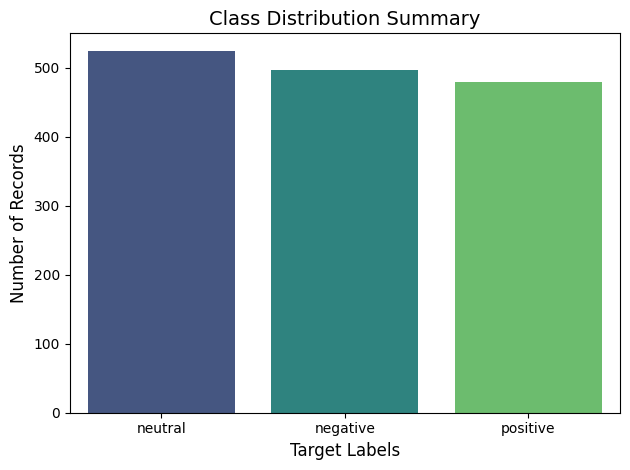

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_csv("customer_support_text_classification.csv")

print("--- Dataset Overview ---")
num_records = len(df)
print(f"Total number of records: {num_records:,}")

unique_classes = df["sentiment_label"].unique()
num_classes = len(unique_classes)
print(f"Number of classes: {num_classes}")
print(f"Target labels: {unique_classes}\n")

print("--- Sample Text Records ---")
samples = df[["customer_message", "sentiment_label"]].sample(
    n=3, random_state=42
)
for idx, row in samples.iterrows():
    print(f"[{row['sentiment_label']}] -> {row['customer_message'][:150]}...")
print("\n")

print("--- Text Length Analysis ---")
df["text_length"] = df["customer_message"].apply(lambda x: len(str(x)))

avg_length = df["text_length"].mean()
median_length = df["text_length"].median()

print(f"Average text length (characters): {avg_length:.2f}")
print(f"Median text length (characters): {median_length:.2f}\n")

print("--- Class Distribution ---")
class_counts = df["sentiment_label"].value_counts()
class_percentages = df["sentiment_label"].value_counts(normalize=True) * 100

dist_df = pd.DataFrame(
    {"Count": class_counts, "Percentage (%)": class_percentages}
)
print(dist_df)

sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis", hue=None)
plt.title("Class Distribution Summary", fontsize=14)
plt.xlabel("Target Labels", fontsize=12)
plt.ylabel("Number of Records", fontsize=12)
plt.tight_layout()
plt.savefig("class_distribution.png")

In [6]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", "", text)
    return text


df["cleaned_message"] = df["customer_message"].apply(preprocess_text)

stop_words = set(ENGLISH_STOP_WORDS)
df["tokenized_no_stopwords"] = df["cleaned_message"].apply(
    lambda x: [word for word in x.split() if word not in stop_words]
)

max_words = 10000
max_len = 50

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(df["cleaned_message"])

sequences = tokenizer.texts_to_sequences(df["cleaned_message"])
padded_sequences = pad_sequences(
    sequences, maxlen=max_len, padding="post", truncating="post"
)

print("Original text sample:", df["customer_message"].iloc[0])
print("Cleaned text sample:", df["cleaned_message"].iloc[0])
print("Tokenized (no stopwords):", df["tokenized_no_stopwords"].iloc[0])
print("Padded sequence shape:", padded_sequences.shape)
print("Padded sequence sample:", padded_sequences[0])

Original text sample: I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
Cleaned text sample: i need information about the payment process my ticket number is 78732 please respond as soon as possible
Tokenized (no stopwords): ['need', 'information', 'payment', 'process', 'ticket', 'number', '78732', 'respond', 'soon', 'possible']
Padded sequence shape: (1500, 50)
Padded sequence sample: [  5  30 137  40   2  91  34   4   7   8   3 185  11  13   9  14   9  15
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = vectorizer.fit_transform(df["customer_message"])

print("Vectorized TF-IDF Matrix Shape:", tfidf_matrix.shape)
print("Sample Features:", vectorizer.get_feature_names_out()[:10])

Vectorized TF-IDF Matrix Shape: (1500, 667)
Sample Features: ['10347' '10565' '10632' '10783' '10841' '10973' '11045' '11058' '11213'
 '11482']


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

X = df["customer_message"]
y = df["sentiment_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000, stop_words="english")
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

print("--- Baseline Model Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

--- Baseline Model Evaluation ---
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

Confusion Matrix:
[[ 99   0   0]
 [  0 105   0]
 [  0   0  96]]


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import LSTM, Dense, Dropout, Embedding
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences

df = pd.read_csv("customer_support_text_classification.csv")

X = df["customer_message"].astype(str)
y = df["sentiment_label"]

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

max_words = 5000
max_len = 50

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(
    X_train_seq, maxlen=max_len, padding="post", truncating="post"
)
X_test_pad = pad_sequences(
    X_test_seq, maxlen=max_len, padding="post", truncating="post"
)

model = Sequential(
    [
        Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
        LSTM(64, dropout=0.2, recurrent_dropout=0.2),
        Dense(32, activation="relu"),
        Dropout(0.2),
        Dense(3, activation="softmax"),
    ]
)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

print(model.summary())

history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_pad, y_test),
)

test_loss, test_accuracy = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"\nFinal Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy:.4f}")

c:\Users\Saket\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.3408 - loss: 1.1004 - val_accuracy: 0.3500 - val_loss: 1.0982
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.3333 - loss: 1.0990 - val_accuracy: 0.3500 - val_loss: 1.0980
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3483 - loss: 1.0982 - val_accuracy: 0.3500 - val_loss: 1.0980
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3483 - loss: 1.0983 - val_accuracy: 0.3500 - val_loss: 1.0979
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.4817 - loss: 0.9899 - val_accuracy: 0.6700 - val_loss: 0.6438

Final Test Loss: 0.6438
Final Test Accuracy: 0.6700


Why RNNs Struggle with Long-Term Dependencies: Recurrent Neural Networks (RNNs) process text sequentially, updating a hidden state at each time step. During training, gradients are calculated backward through time. To compute the gradient of the loss at a distant future step with respect to an early hidden state, the chain rule requires a continuous sequence of matrix multiplications. If the weights are small, multiplying them repeatedly across many time steps causes the gradient to decrease exponentially toward zero. This is known as the vanishing gradient problem. Consequently, the network cannot update its early weights effectively, causing it to lose context from the beginning of long sentences.

How LSTMs Help with Memory: Long Short-Term Memory (LSTM) networks solve the vanishing gradient problem by introducing an explicit cell state, which acts as an internal linear conveyor belt running through the sequence. Instead of applying raw multiplicative transformations at every step, the cell state updates using an additive mechanism controlled by three regulatory gates: the Forget Gate (decides what information to discard), the Input Gate (decides which new information to store), and the Output Gate (decides what parts of the updated cell state to export to the next hidden state). Because the error gradient can flow backward through additive operations without being repeatedly scaled down, the gradient remains stable over long sequences.

What Attention Solves in Sequence-to-Sequence Tasks: Traditional Encoder-Decoder models suffer from an information bottleneck where the encoder compresses an entire input sentence of arbitrary length into a single, fixed-size context vector before handing it over to the decoder. If a message is long or complex, this single vector fails to retain all vital details. The Attention Mechanism eliminates this bottleneck by allowing the decoder to look back at all encoder hidden states dynamically at every single decoding step. The model calculates alignment scores, normalizes them into attention weights, and takes a weighted sum of the encoder states to create a tailored context vector for the specific word it is currently generating.

Why Transformers Are Important in Modern NLP and Generative AI: The Transformer architecture completely discards recurrent layers in favor of Self-Attention. This structural change is a massive milestone for two primary reasons: first, it allows massive parallelization because the model processes an entire sequence of tokens simultaneously rather than step-by-step; second, it enables global context routing where every word computes a relationship with every other word in the sequence instantly, eliminating the need to pass information through long temporal chains. This scaling capacity forms the direct foundation for modern Large Language Models and generative systems.